# Advanced EDA and Feature Engineering for E-Commerce Orders
## Project Overview
This notebook implements Project 1: Advanced EDA and Feature Engineering on an e-commerce orders dataset.

## Objective:
Transform raw transactional order data into a mathematically clean, feature-rich, machine-learning-ready dataset.

## Scope:

Load data from the provided Google Sheets dataset

Validate structural integrity

Handle missing values using a decision-matrix approach

Detect and neutralize outliers using IQR-based winsorization

Engineer predictive business features

Translate categorical variables into coordinate space using One-Hot Encoding

Reduce multicollinearity

Export clean feature-store and ML-ready datasets

Save a production-ready feature engineering artifact

#####  Project Type: Data preprocessing, EDA, and feature engineering

#####  Supervised Model Training: Not performed in P1

#####  Business Anchor for Numeric Analysis: TotalPrice

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

Project root: C:\Users\Kyous\Videos\Internship\Project 1\Project 1
Processed data directory: C:\Users\Kyous\Videos\Internship\Project 1\Project 1\data\processed
Artifacts directory: C:\Users\Kyous\Videos\Internship\Project 1\Project 1\artifacts


## Environment and Project Structure
The project directories are created for reproducibility and clean separation of concerns:

data/raw: original dataset snapshot

data/processed: cleaned and ML-ready datasets

reports/figures: visual 

artifacts: saved feature engineering pipeline metadata

In [3]:
SHEET_ID = "1N4-eLmaH5I2oNfUTh-qppwjMmC0Ktqhh"
GID = "727130089"

DATA_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

raw_df = pd.read_csv(DATA_URL)

raw_snapshot_path = RAW_DATA_DIR / "p1_orders_raw_google_sheet_export.csv"
raw_df.to_csv(raw_snapshot_path, index=False)

print(f"Raw dataset shape: {raw_df.shape}")
display(raw_df.head())

Raw dataset shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6200,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.1000"
1,ORD200001,2024-08-23,C75739,Phone,2,151.3500,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.6800,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.4000"
3,ORD200003,2023-10-15,C33540,Chair,1,273.1900,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.1900
4,ORD200004,2025-05-08,C81840,Printer,4,626.0100,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.0400"


## Data Loading
The dataset is loaded directly from the provided Google Sheets link using a CSV export URL.

A raw snapshot is saved locally to preserve the original input state for auditability.

In [3]:
EXPECTED_COLUMNS = [
    "OrderID",
    "Date",
    "CustomerID",
    "Product",
    "Quantity",
    "UnitPrice",
    "ShippingAddress",
    "PaymentMethod",
    "OrderStatus",
    "TrackingNumber",
    "ItemsInCart",
    "CouponCode",
    "ReferralSource",
    "TotalPrice",
]

def normalize_column_names(input_df: pd.DataFrame) -> pd.DataFrame:
    df = input_df.copy()
    normalized_columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.replace(r"[\s_]+", "", regex=True)
        .str.replace(r"[^A-Za-z0-9]", "", regex=True)
    )
    canonical_lookup = {column.lower(): column for column in EXPECTED_COLUMNS}
    df.columns = [canonical_lookup.get(column.lower(), column) for column in normalized_columns]
    return df

raw_df_normalized = normalize_column_names(raw_df)

missing_required_columns = sorted(set(EXPECTED_COLUMNS) - set(raw_df_normalized.columns))
extra_columns = sorted(set(raw_df_normalized.columns) - set(EXPECTED_COLUMNS))

schema_report = pd.DataFrame({
    "missing_required_columns": [", ".join(missing_required_columns) if missing_required_columns else "None"],
    "extra_columns": [", ".join(extra_columns) if extra_columns else "None"],
    "schema_status": ["PASS" if not missing_required_columns else "FAIL"]
})

display(schema_report)

assert not missing_required_columns, f"Missing required columns: {missing_required_columns}"

df = raw_df_normalized[EXPECTED_COLUMNS].copy()
display(df.head())

,missing_required_columns,extra_columns,schema_status
0,None,None,PASS


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6200,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.1000"
1,ORD200001,2024-08-23,C75739,Phone,2,151.3500,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.6800,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.4000"
3,ORD200003,2023-10-15,C33540,Chair,1,273.1900,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.1900
4,ORD200004,2025-05-08,C81840,Printer,4,626.0100,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.0400"


## Schema Normalization
Column names are standardized and validated against the expected e-commerce order schema.

This prevents silent corruption caused by spacing inconsistencies or spreadsheet export formatting.

In [4]:
TEXT_COLUMNS = [
    "OrderID",
    "CustomerID",
    "Product",
    "ShippingAddress",
    "PaymentMethod",
    "OrderStatus",
    "TrackingNumber",
    "CouponCode",
    "ReferralSource",
]

NUMERIC_COLUMNS = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
]

def normalize_and_cast_orders(input_df: pd.DataFrame) -> pd.DataFrame:
    df = input_df.copy()

    text_columns_available = [column for column in TEXT_COLUMNS if column in df.columns]
    numeric_columns_available = [column for column in NUMERIC_COLUMNS if column in df.columns]

    df[text_columns_available] = (
        df[text_columns_available]
        .astype("string")
        .apply(lambda column: column.str.strip())
    )

    blank_like_values = ["", "nan", "NaN", "None", "NONE", "null", "NULL", "<NA>"]
    df[text_columns_available] = df[text_columns_available].replace(blank_like_values, pd.NA)

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[numeric_columns_available] = df[numeric_columns_available].apply(pd.to_numeric, errors="coerce")

    df["OrderID"] = df["OrderID"].str.upper()
    df["CustomerID"] = df["CustomerID"].str.upper()
    df["TrackingNumber"] = df["TrackingNumber"].str.upper()

    return df

base_df = normalize_and_cast_orders(df)

display(base_df.dtypes.to_frame("dtype"))
display(base_df.head())

,dtype
OrderID,string[python]
Date,datetime64[ns]
CustomerID,string[python]
Product,string[python]
Quantity,int64
UnitPrice,float64
ShippingAddress,string[python]
PaymentMethod,string[python]
OrderStatus,string[python]
TrackingNumber,string[python]


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6200,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.1000"
1,ORD200001,2024-08-23,C75739,Phone,2,151.3500,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.6800,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.4000"
3,ORD200003,2023-10-15,C33540,Chair,1,273.1900,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.1900
4,ORD200004,2025-05-08,C81840,Printer,4,626.0100,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.0400"


## Type Casting
The dataset is converted into analysis-ready types:

Dates are parsed as datetime

Numeric business fields are converted to numeric types

Text fields are stripped and standardized

Blank-like values are converted to missing values

In [5]:
schema_profile = pd.DataFrame({
    "dtype": base_df.dtypes.astype(str),
    "non_null_count": base_df.notna().sum(),
    "missing_count": base_df.isna().sum(),
    "missing_rate": base_df.isna().mean(),
    "unique_count": base_df.nunique(dropna=True),
    "sample_value": base_df.apply(lambda column: column.dropna().iloc[0] if column.dropna().shape[0] else pd.NA)
}).sort_values("missing_rate", ascending=False)

display(schema_profile)

,dtype,non_null_count,missing_count,missing_rate,unique_count,sample_value
CouponCode,string,891,309,0.2575,3,SAVE10
OrderID,string,1200,0,0.0000,1200,ORD200000
Date,datetime64[ns],1200,0,0.0000,671,2023-01-04 00:00:00
CustomerID,string,1200,0,0.0000,1189,C72649
Product,string,1200,0,0.0000,7,Monitor
Quantity,int64,1200,0,0.0000,5,5
UnitPrice,float64,1200,0,0.0000,1193,570.6200
ShippingAddress,string,1200,0,0.0000,655,928 Main St
PaymentMethod,string,1200,0,0.0000,5,Debit Card
OrderStatus,string,1200,0,0.0000,5,Shipped


## Input Fidelity Profile
This profile gives a compact view of column quality:

Missingness

Cardinality

Data type

Representative values

###### It supports early decisions before any transformation is applied.

In [6]:
VALID_PRODUCTS = {"Monitor", "Phone", "Tablet", "Chair", "Printer", "Laptop", "Desk"}
VALID_PAYMENT_METHODS = {"Debit Card", "Credit Card", "Online", "Gift Card", "Cash"}
VALID_ORDER_STATUSES = {"Shipped", "Delivered", "Cancelled", "Returned", "Pending"}
VALID_REFERRAL_SOURCES = {"Instagram", "Referral", "Email", "Facebook", "Google"}
VALID_COUPON_CODES = {"SAVE10", "FREESHIP", "WINTER15", "NO_COUPON"}

def build_contract_report(input_df: pd.DataFrame) -> pd.DataFrame:
    df = input_df.copy()

    expected_total = (df["Quantity"] * df["UnitPrice"]).round(2)
    total_price_mismatch = ~np.isclose(df["TotalPrice"], expected_total, atol=0.02, equal_nan=False)

    checks = [
        {
            "check": "Required columns present",
            "passed": set(EXPECTED_COLUMNS).issubset(df.columns),
            "failed_rows": len(set(EXPECTED_COLUMNS) - set(df.columns)),
            "business_impact": "Schema mismatch blocks reliable downstream processing",
        },
        {
            "check": "OrderID uniqueness",
            "passed": df["OrderID"].is_unique,
            "failed_rows": int(df["OrderID"].duplicated().sum()),
            "business_impact": "Duplicate order IDs can inflate revenue and order counts",
        },
        {
            "check": "TrackingNumber uniqueness",
            "passed": df["TrackingNumber"].is_unique,
            "failed_rows": int(df["TrackingNumber"].duplicated().sum()),
            "business_impact": "Duplicate tracking numbers indicate fulfillment data risk",
        },
        {
            "check": "Date parse validity",
            "passed": df["Date"].notna().all(),
            "failed_rows": int(df["Date"].isna().sum()),
            "business_impact": "Invalid dates break temporal analysis",
        },
        {
            "check": "Positive quantity",
            "passed": df["Quantity"].ge(1).all(),
            "failed_rows": int(df["Quantity"].lt(1).sum()),
            "business_impact": "Invalid quantities distort revenue calculations",
        },
        {
            "check": "Positive unit price",
            "passed": df["UnitPrice"].gt(0).all(),
            "failed_rows": int(df["UnitPrice"].le(0).sum()),
            "business_impact": "Invalid prices create financial reporting errors",
        },
        {
            "check": "Positive total price",
            "passed": df["TotalPrice"].gt(0).all(),
            "failed_rows": int(df["TotalPrice"].le(0).sum()),
            "business_impact": "Invalid totals affect revenue integrity",
        },
        {
            "check": "TotalPrice equals Quantity x UnitPrice",
            "passed": not total_price_mismatch.any(),
            "failed_rows": int(total_price_mismatch.sum()),
            "business_impact": "Mismatch indicates pricing, discount, or extraction inconsistency",
        },
    ]

    category_domains = {
        "Product": VALID_PRODUCTS,
        "PaymentMethod": VALID_PAYMENT_METHODS,
        "OrderStatus": VALID_ORDER_STATUSES,
        "ReferralSource": VALID_REFERRAL_SOURCES,
    }

    for column, valid_values in category_domains.items():
        invalid_mask = df[column].notna() & ~df[column].isin(valid_values)
        checks.append({
            "check": f"{column} domain validity",
            "passed": not invalid_mask.any(),
            "failed_rows": int(invalid_mask.sum()),
            "business_impact": f"Unexpected {column} values can break encoding and reporting",
        })

    return pd.DataFrame(checks)

contract_report = build_contract_report(base_df)
display(contract_report)

,check,passed,failed_rows,business_impact
0,Required columns present,True,0,Schema mismatch blocks reliable downstream pro...
1,OrderID uniqueness,True,0,Duplicate order IDs can inflate revenue and or...
2,TrackingNumber uniqueness,True,0,Duplicate tracking numbers indicate fulfillmen...
3,Date parse validity,True,0,Invalid dates break temporal analysis
4,Positive quantity,True,0,Invalid quantities distort revenue calculations
5,Positive unit price,True,0,Invalid prices create financial reporting errors
6,Positive total price,True,0,Invalid totals affect revenue integrity
7,TotalPrice equals Quantity x UnitPrice,True,0,"Mismatch indicates pricing, discount, or extra..."
8,Product domain validity,True,0,Unexpected Product values can break encoding a...
9,PaymentMethod domain validity,True,0,Unexpected PaymentMethod values can break enco...


## Structural Contract Validation
A lazy validation report is generated instead of stopping at the first issue.

This mirrors production contract thinking: collect all structural failures before deciding remediation.

In [7]:
missing_summary = (
    base_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_rate"] = base_df.isna().mean()

missing_summary["decision_matrix_action"] = np.select(
    [
        missing_summary["missing_rate"].eq(0),
        missing_summary["missing_rate"].gt(0) & missing_summary["missing_rate"].lt(0.05),
        missing_summary["missing_rate"].ge(0.05) & missing_summary["missing_rate"].le(0.20),
        missing_summary["missing_rate"].gt(0.20),
    ],
    [
        "No action required",
        "Drop rows if field is critical; otherwise impute",
        "Statistical imputation",
        "Multi-dimensional imputation or feature exclusion review",
    ],
    default="Manual review required",
)

missing_summary = missing_summary.sort_values("missing_rate", ascending=False)

display(missing_summary)

,missing_count,missing_rate,decision_matrix_action
CouponCode,309,0.2575,Multi-dimensional imputation or feature exclus...
OrderID,0,0.0000,No action required
Date,0,0.0000,No action required
CustomerID,0,0.0000,No action required
Product,0,0.0000,No action required
Quantity,0,0.0000,No action required
UnitPrice,0,0.0000,No action required
ShippingAddress,0,0.0000,No action required
PaymentMethod,0,0.0000,No action required
OrderStatus,0,0.0000,No action required


## Missing Data Decision Matrix
#### Missingness is classified using practical thresholds:

0%: no action

<5%: drop rows only if business-critical

5%-20%: statistical imputation

 .>20%: multi-dimensional imputation or feature review

In [8]:
TRAINING_CRITICAL_COLUMNS = [
    "OrderID",
    "Date",
    "CustomerID",
    "Product",
    "Quantity",
    "UnitPrice",
    "PaymentMethod",
    "OrderStatus",
    "TrackingNumber",
    "ItemsInCart",
    "ReferralSource",
    "TotalPrice",
]

SERVING_REQUIRED_COLUMNS = [
    "Date",
    "Product",
    "Quantity",
    "UnitPrice",
    "PaymentMethod",
    "OrderStatus",
    "ItemsInCart",
    "ReferralSource",
]

working_df = base_df.copy()

rows_before_missing_policy = working_df.shape[0]
working_df = working_df.dropna(subset=TRAINING_CRITICAL_COLUMNS).copy()
rows_after_critical_drop = working_df.shape[0]

working_df["CouponCode"] = working_df["CouponCode"].fillna("NO_COUPON")

numeric_impute_values = working_df[NUMERIC_COLUMNS].median(numeric_only=True)
working_df[NUMERIC_COLUMNS] = working_df[NUMERIC_COLUMNS].fillna(numeric_impute_values)

categorical_impute_columns = [
    "Product",
    "ShippingAddress",
    "PaymentMethod",
    "OrderStatus",
    "TrackingNumber",
    "CouponCode",
    "ReferralSource",
]

categorical_impute_values = working_df[categorical_impute_columns].mode(dropna=True).iloc[0].to_dict()
categorical_impute_values["CouponCode"] = "NO_COUPON"

working_df[categorical_impute_columns] = working_df[categorical_impute_columns].fillna(
    pd.Series(categorical_impute_values)
)

missing_policy_report = pd.DataFrame({
    "metric": [
        "Rows before missing-value policy",
        "Rows after critical-field row removal",
        "Rows removed",
        "Remaining missing values",
    ],
    "value": [
        rows_before_missing_policy,
        rows_after_critical_drop,
        rows_before_missing_policy - rows_after_critical_drop,
        int(working_df.isna().sum().sum()),
    ]
})

display(missing_policy_report)

,metric,value
0,Rows before missing-value policy,1200
1,Rows after critical-field row removal,1200
2,Rows removed,0
3,Remaining missing values,0


## Missing Value Treatment
Critical fields are protected by row-level removal if incomplete.

Non-critical values are imputed using stable statistical defaults:

Numeric fields: median
    
Categorical fields: mode
    
Missing coupons: NO_COUPON

In [9]:
duplicate_report = pd.DataFrame({
    "check": [
        "Duplicate full rows",
        "Duplicate OrderID",
        "Duplicate TrackingNumber",
        "Repeated CustomerID count",
    ],
    "count": [
        int(working_df.duplicated().sum()),
        int(working_df["OrderID"].duplicated().sum()),
        int(working_df["TrackingNumber"].duplicated().sum()),
        int(working_df["CustomerID"].duplicated().sum()),
    ],
    "action": [
        "Drop exact duplicates",
        "Keep first occurrence if present",
        "Review fulfillment duplication if present",
        "Allowed because customers may place multiple orders",
    ]
})

clean_df = (
    working_df
    .drop_duplicates()
    .drop_duplicates(subset="OrderID", keep="first")
    .copy()
)

display(duplicate_report)
print(f"Clean dataset shape after duplicate handling: {clean_df.shape}")

,check,count,action
0,Duplicate full rows,0,Drop exact duplicates
1,Duplicate OrderID,0,Keep first occurrence if present
2,Duplicate TrackingNumber,0,Review fulfillment duplication if present
3,Repeated CustomerID count,11,Allowed because customers may place multiple o...


Clean dataset shape after duplicate handling: (1200, 14)


## Duplicate Handling
Order-level uniqueness is enforced using OrderID.

Repeated customers are retained because repeat purchasing is expected and business-relevant.

In [10]:
numeric_eda_summary = clean_df[NUMERIC_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numeric_eda_summary["skewness"] = clean_df[NUMERIC_COLUMNS].skew()

categorical_eda_columns = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource",
]

categorical_eda_summary = pd.DataFrame({
    "unique_count": clean_df[categorical_eda_columns].nunique(dropna=True),
    "top_value": clean_df[categorical_eda_columns].mode(dropna=True).iloc[0],
    "top_frequency": clean_df[categorical_eda_columns].apply(
        lambda column: column.value_counts(dropna=False).iloc[0]
    ),
})

display(numeric_eda_summary)
display(categorical_eda_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness
Quantity,"1,200.0000",2.9458,1.4076,1.0000,1.0000,1.0000,2.0000,3.0000,4.0000,5.0000,5.0000,5.0000,0.0279
UnitPrice,"1,200.0000",356.4128,197.1771,11.3900,21.1888,49.1370,186.0625,364.2100,521.5700,660.7215,692.9116,699.9300,-0.0265
ItemsInCart,"1,200.0000",5.4850,2.2820,1.0000,1.0000,2.0000,4.0000,5.0000,7.0000,9.0000,10.0000,10.0000,0.0009
TotalPrice,"1,200.0000","1,053.9683",819.8566,11.3900,36.5889,97.8075,410.5200,823.6150,"1,578.4750","2,666.4480","3,277.9110","3,456.4000",0.8914


,unique_count,top_value,top_frequency
Product,7,Printer,181
PaymentMethod,5,Online,258
OrderStatus,5,Cancelled,250
CouponCode,4,FREESHIP,313
ReferralSource,5,Instagram,259


## Core EDA Summary
Numeric and categorical summaries establish the data baseline before feature engineering.

This helps identify distribution shape, dominant categories, and revenue-driving fields.

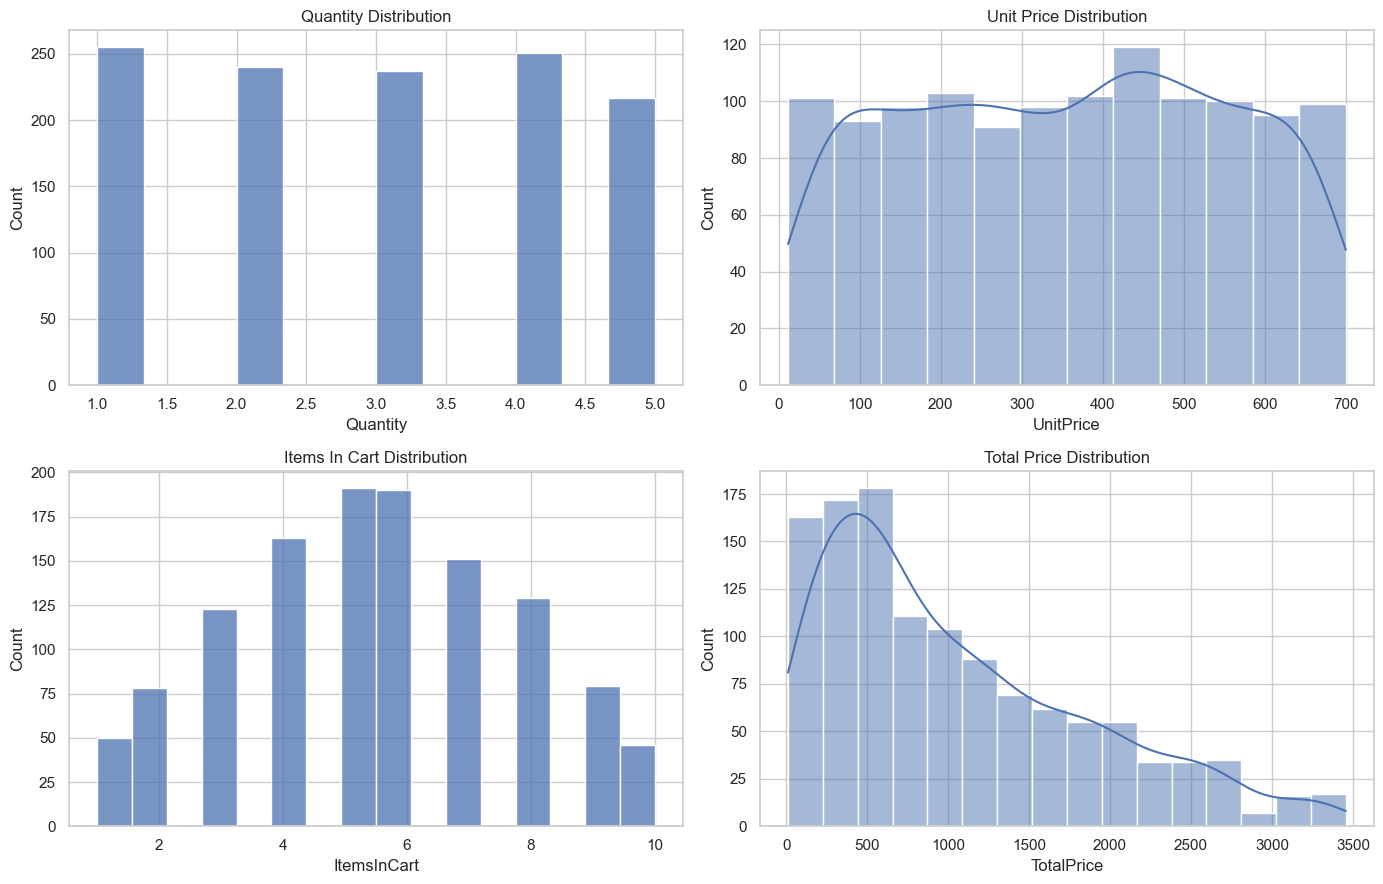

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(clean_df["Quantity"], kde=False, ax=axes[0, 0])
axes[0, 0].set_title("Quantity Distribution")

sns.histplot(clean_df["UnitPrice"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Unit Price Distribution")

sns.histplot(clean_df["ItemsInCart"], kde=False, ax=axes[1, 0])
axes[1, 0].set_title("Items In Cart Distribution")

sns.histplot(clean_df["TotalPrice"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Total Price Distribution")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "p1_numeric_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## Business EDA
#### Business aggregations quantify:

Order status mix

Revenue by product

Payment-method status patterns

Referral-source contribution

These outputs support business-facing interpretation, not just technical cleaning.

In [13]:
product_performance = (
    clean_df
    .groupby("Product", as_index=False)["TotalPrice"]
    .sum()
    .rename(columns={"TotalPrice": "Revenue"})
)

referral_performance = (
    clean_df
    .groupby("ReferralSource", as_index=False)["TotalPrice"]
    .sum()
    .rename(columns={"TotalPrice": "Revenue"})
)

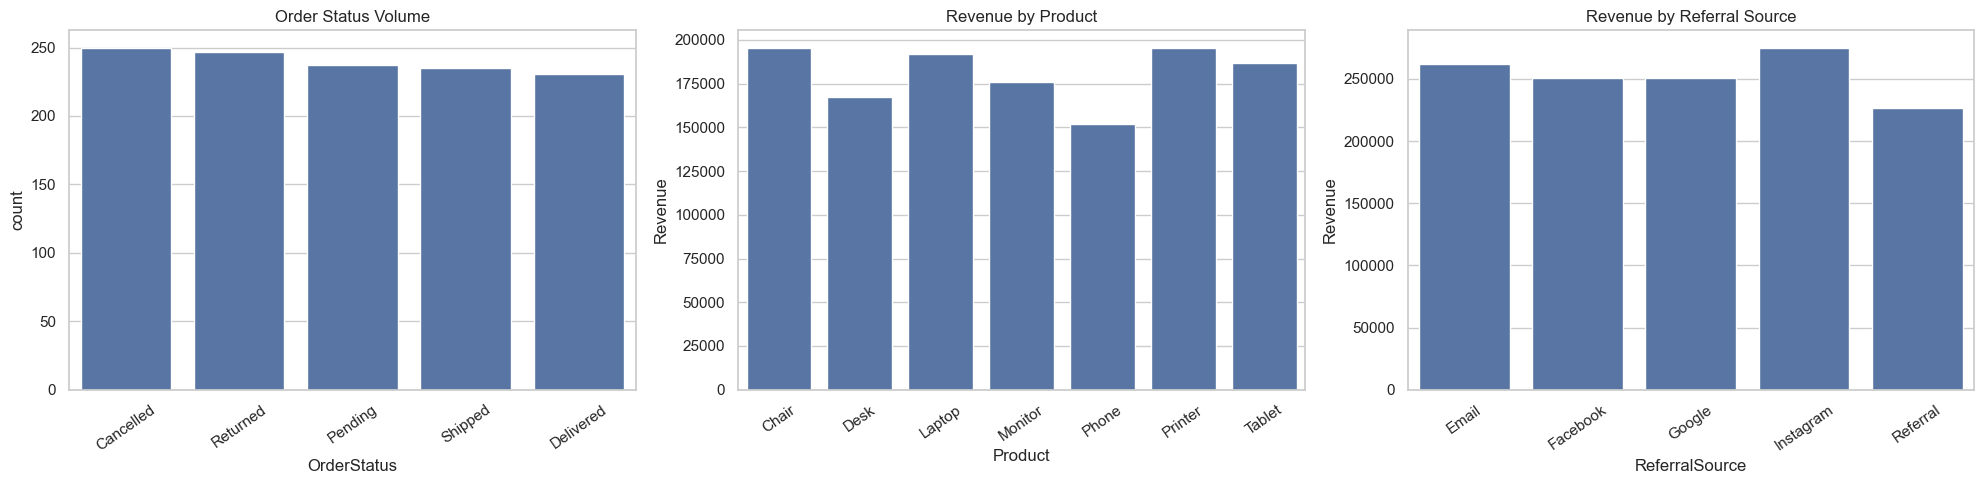

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(
    data=clean_df,
    x="OrderStatus",
    order=clean_df["OrderStatus"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Order Status Volume")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=product_performance,
    x="Product",
    y="Revenue",
    ax=axes[1]
)
axes[1].set_title("Revenue by Product")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(
    data=referral_performance,
    x="ReferralSource",
    y="Revenue",
    ax=axes[2]
)
axes[2].set_title("Revenue by Referral Source")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "p1_business_eda_overview.png", dpi=160, bbox_inches="tight")
plt.show()

## Business Visuals
These plots make operational patterns visible:

Which statuses dominate the order lifecycle

Which products drive revenue

Which acquisition channels contribute most revenue

,Date,Orders,Revenue,AverageOrderValue
18,2024-07-01,43,"42,963.9800",999.1623
19,2024-08-01,28,"31,991.0700","1,142.5382"
20,2024-09-01,44,"39,794.9800",904.4314
21,2024-10-01,31,"37,226.9700","1,200.8700"
22,2024-11-01,35,"32,413.7600",926.1074
23,2024-12-01,41,"38,785.7700",945.9944
24,2025-01-01,27,"29,099.4000","1,077.7556"
25,2025-02-01,37,"35,317.5500",954.5284
26,2025-03-01,49,"39,200.6600",800.0135
27,2025-04-01,32,"31,821.2000",994.4125


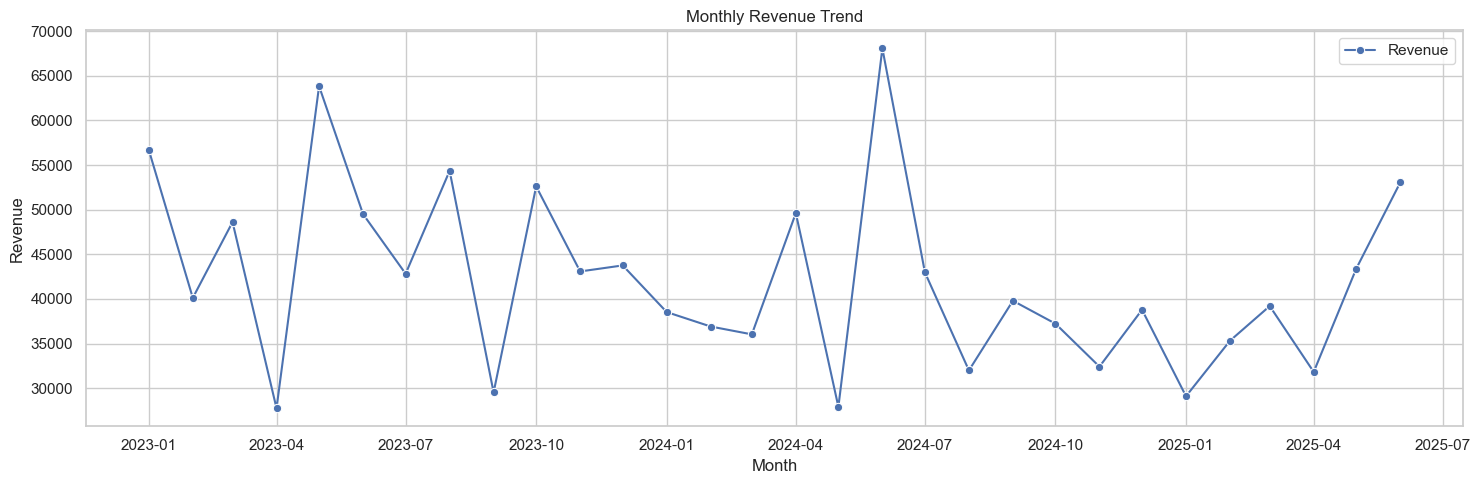

In [15]:
monthly_performance = (
    clean_df
    .set_index("Date")
    .sort_index()
    .resample("MS")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
    )
    .reset_index()
)

display(monthly_performance.tail(12))

fig, ax1 = plt.subplots(figsize=(15, 5))

sns.lineplot(
    data=monthly_performance,
    x="Date",
    y="Revenue",
    marker="o",
    ax=ax1,
    label="Revenue"
)

ax1.set_title("Monthly Revenue Trend")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "p1_monthly_revenue_trend.png", dpi=160, bbox_inches="tight")
plt.show()

## Temporal EDA
Monthly revenue behavior is analyzed to detect trend shifts and seasonality.

Date-based features are later engineered from this timestamp structure.

In [16]:
UNIT_PRICE_LABELS = ["Budget", "Standard", "High", "Luxury"]
ORDER_VALUE_LABELS = ["Low", "Medium", "High", "Premium"]

unit_price_quantiles = clean_df["UnitPrice"].quantile([0.25, 0.50, 0.75]).round(6).tolist()
total_price_quantiles = clean_df["TotalPrice"].quantile([0.25, 0.50, 0.75]).round(6).tolist()

UNIT_PRICE_BINS = [-np.inf] + unit_price_quantiles + [np.inf]
TOTAL_PRICE_BINS = [-np.inf] + total_price_quantiles + [np.inf]

def engineer_order_features(
    input_df: pd.DataFrame,
    unit_price_bins: list,
    total_price_bins: list
) -> pd.DataFrame:
    df = input_df.copy()

    df["OrderYear"] = df["Date"].dt.year.astype("Int16")
    df["OrderQuarter"] = df["Date"].dt.quarter.astype("Int8")
    df["OrderMonth"] = df["Date"].dt.month.astype("Int8")
    df["OrderDayOfWeek"] = df["Date"].dt.dayofweek.astype("Int8")
    df["IsWeekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype("int8")

    df["OrderMonthSin"] = np.sin(2 * np.pi * df["OrderMonth"].astype(float) / 12)
    df["OrderMonthCos"] = np.cos(2 * np.pi * df["OrderMonth"].astype(float) / 12)

    df["ComputedGrossPrice"] = (df["Quantity"] * df["UnitPrice"]).round(2)
    df["TotalPriceDelta"] = (df["TotalPrice"] - df["ComputedGrossPrice"]).round(2)
    df["TotalPriceDeltaAbs"] = df["TotalPriceDelta"].abs()

    df["HasCoupon"] = df["CouponCode"].ne("NO_COUPON").astype("int8")

    df["CouponFamily"] = np.select(
        [
            df["CouponCode"].eq("FREESHIP"),
            df["CouponCode"].eq("SAVE10"),
            df["CouponCode"].eq("WINTER15"),
            df["CouponCode"].eq("NO_COUPON"),
        ],
        [
            "FreeShipping",
            "Discount10",
            "Seasonal15",
            "NoCoupon",
        ],
        default="OtherCoupon"
    )

    df["IsDigitalPayment"] = df["PaymentMethod"].isin(
        ["Online", "Credit Card", "Debit Card", "Gift Card"]
    ).astype("int8")

    df["CartUtilization"] = (
        df["Quantity"] / df["ItemsInCart"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan).fillna(0)

    df["GrossCartValue"] = (df["ItemsInCart"] * df["UnitPrice"]).round(2)
    df["UnpurchasedCartItems"] = (df["ItemsInCart"] - df["Quantity"]).clip(lower=0)
    df["UnpurchasedCartValue"] = (df["UnpurchasedCartItems"] * df["UnitPrice"]).round(2)

    df["AddressNumber"] = pd.to_numeric(
        df["ShippingAddress"].astype("string").str.extract(r"(\d+)", expand=False),
        errors="coerce"
    )

    df["UnitPriceTier"] = pd.cut(
        df["UnitPrice"],
        bins=unit_price_bins,
        labels=UNIT_PRICE_LABELS,
        include_lowest=True
    ).astype("string")

    df["OrderValueSegment"] = pd.cut(
        df["TotalPrice"],
        bins=total_price_bins,
        labels=ORDER_VALUE_LABELS,
        include_lowest=True
    ).astype("string")

    df["UnitPriceTier"] = df["UnitPriceTier"].fillna("Unknown")
    df["OrderValueSegment"] = df["OrderValueSegment"].fillna("Unknown")

    return df

featured_df = engineer_order_features(
    clean_df,
    unit_price_bins=UNIT_PRICE_BINS,
    total_price_bins=TOTAL_PRICE_BINS
)

engineered_columns = [
    "OrderYear",
    "OrderQuarter",
    "OrderMonth",
    "OrderDayOfWeek",
    "IsWeekend",
    "OrderMonthSin",
    "OrderMonthCos",
    "ComputedGrossPrice",
    "TotalPriceDelta",
    "TotalPriceDeltaAbs",
    "HasCoupon",
    "CouponFamily",
    "IsDigitalPayment",
    "CartUtilization",
    "GrossCartValue",
    "UnpurchasedCartItems",
    "UnpurchasedCartValue",
    "AddressNumber",
    "UnitPriceTier",
    "OrderValueSegment",
]

display(featured_df[["OrderID"] + engineered_columns].head())

,OrderID,OrderYear,OrderQuarter,OrderMonth,OrderDayOfWeek,IsWeekend,OrderMonthSin,OrderMonthCos,ComputedGrossPrice,TotalPriceDelta,TotalPriceDeltaAbs,HasCoupon,CouponFamily,IsDigitalPayment,CartUtilization,GrossCartValue,UnpurchasedCartItems,UnpurchasedCartValue,AddressNumber,UnitPriceTier,OrderValueSegment
0,ORD200000,2023,1,1,2,0,0.5000,0.8660,"2,853.1000",0.0000,0.0000,1,Discount10,1,0.7143,"3,994.3400",2,"1,141.2400",928,Luxury,Premium
1,ORD200001,2024,3,8,4,0,-0.8660,-0.5000,302.7000,0.0000,0.0000,1,Discount10,1,0.6667,454.0500,1,151.3500,823,Budget,Low
2,ORD200002,2024,1,2,1,0,0.8660,0.5000,"2,753.4000",0.0000,0.0000,1,FreeShipping,1,0.6250,"4,405.4400",3,"1,652.0400",512,Luxury,Premium
3,ORD200003,2023,4,10,6,1,-0.8660,0.5000,273.1900,0.0000,0.0000,1,Discount10,1,0.2000,"1,365.9500",4,"1,092.7600",275,Standard,Low
4,ORD200004,2025,2,5,3,0,0.5000,-0.8660,"2,504.0400",0.0000,0.0000,1,Discount10,1,0.5000,"5,008.0800",4,"2,504.0400",668,Luxury,Premium


## Feature Engineering
New predictive features are engineered from existing fields, including:

Calendar features

Cyclical month encoding

Coupon behavior

Payment behavior

Cart utilization

Cart value potential

Price and order value tiers

Revenue integrity features

These features improve downstream model readiness without procedural row-wise logic.

In [17]:
engineered_feature_profile = pd.DataFrame({
    "dtype": featured_df[engineered_columns].dtypes.astype(str),
    "missing_count": featured_df[engineered_columns].isna().sum(),
    "missing_rate": featured_df[engineered_columns].isna().mean(),
    "unique_count": featured_df[engineered_columns].nunique(dropna=True),
    "sample_value": featured_df[engineered_columns].apply(
        lambda column: column.dropna().iloc[0] if column.dropna().shape[0] else pd.NA
    )
})

display(engineered_feature_profile)

,dtype,missing_count,missing_rate,unique_count,sample_value
OrderYear,Int16,0,0.0000,3,2023
OrderQuarter,Int8,0,0.0000,4,1
OrderMonth,Int8,0,0.0000,12,1
OrderDayOfWeek,Int8,0,0.0000,7,2
IsWeekend,int8,0,0.0000,2,0
OrderMonthSin,float64,0,0.0000,11,0.5000
OrderMonthCos,float64,0,0.0000,11,0.8660
ComputedGrossPrice,float64,0,0.0000,1195,"2,853.1000"
TotalPriceDelta,float64,0,0.0000,1,0.0000
TotalPriceDeltaAbs,float64,0,0.0000,1,0.0000


## Engineered Feature Audit
Every engineered feature is profiled for type, missingness, uniqueness, and sample values.

This ensures feature logic is auditable before export.

In [18]:
CONTINUOUS_NUMERIC_COLUMNS = [
    "UnitPrice",
    "TotalPrice",
    "ComputedGrossPrice",
    "CartUtilization",
    "GrossCartValue",
    "UnpurchasedCartValue",
    "AddressNumber",
]

CONTINUOUS_NUMERIC_COLUMNS = [
    column for column in CONTINUOUS_NUMERIC_COLUMNS
    if column in featured_df.columns
]

q1 = featured_df[CONTINUOUS_NUMERIC_COLUMNS].quantile(0.25)
q3 = featured_df[CONTINUOUS_NUMERIC_COLUMNS].quantile(0.75)
iqr = q3 - q1

lower_bounds = q1 - (1.5 * iqr)
upper_bounds = q3 + (1.5 * iqr)

outlier_mask = (
    featured_df[CONTINUOUS_NUMERIC_COLUMNS].lt(lower_bounds, axis=1)
    | featured_df[CONTINUOUS_NUMERIC_COLUMNS].gt(upper_bounds, axis=1)
)

outlier_report = pd.DataFrame({
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "lower_bound": lower_bounds,
    "upper_bound": upper_bounds,
    "outlier_count": outlier_mask.sum(),
    "outlier_rate": outlier_mask.mean(),
}).sort_values("outlier_rate", ascending=False)

display(outlier_report)

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_rate
TotalPrice,410.5200,"1,578.4750","1,167.9550","-1,341.4125","3,330.4075",8,0.0067
ComputedGrossPrice,410.5200,"1,578.4750","1,167.9550","-1,341.4125","3,330.4075",8,0.0067
GrossCartValue,776.6050,"2,891.9475","2,115.3425","-2,396.4088","6,064.9613",8,0.0067
UnpurchasedCartValue,193.5950,"1,443.9975","1,250.4025","-1,682.0087","3,319.6012",8,0.0067
UnitPrice,186.0625,521.5700,335.5075,-317.1987,"1,024.8312",0,0.0000
CartUtilization,0.4000,0.7500,0.3500,-0.1250,1.2750,0,0.0000
AddressNumber,326.7500,803.2500,476.5000,-388.0000,"1,518.0000",0,0.0000


## IQR Outlier Detection
Outliers are isolated using the Interquartile Range method.

This method is robust for skewed transactional data and avoids assumptions of normality.

In [19]:
winsorized_df = featured_df.copy()

winsorized_df[CONTINUOUS_NUMERIC_COLUMNS] = featured_df[CONTINUOUS_NUMERIC_COLUMNS].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

post_winsor_mask = (
    winsorized_df[CONTINUOUS_NUMERIC_COLUMNS].lt(lower_bounds, axis=1)
    | winsorized_df[CONTINUOUS_NUMERIC_COLUMNS].gt(upper_bounds, axis=1)
)

winsorization_report = pd.DataFrame({
    "feature": CONTINUOUS_NUMERIC_COLUMNS,
    "outliers_before": outlier_mask.sum().reindex(CONTINUOUS_NUMERIC_COLUMNS).values,
    "outliers_after": post_winsor_mask.sum().reindex(CONTINUOUS_NUMERIC_COLUMNS).values,
    "lower_bound": lower_bounds.reindex(CONTINUOUS_NUMERIC_COLUMNS).values,
    "upper_bound": upper_bounds.reindex(CONTINUOUS_NUMERIC_COLUMNS).values,
})

display(winsorization_report)

,feature,outliers_before,outliers_after,lower_bound,upper_bound
0,UnitPrice,0,0,-317.1987,"1,024.8312"
1,TotalPrice,8,0,"-1,341.4125","3,330.4075"
2,ComputedGrossPrice,8,0,"-1,341.4125","3,330.4075"
3,CartUtilization,0,0,-0.1250,1.2750
4,GrossCartValue,8,0,"-2,396.4088","6,064.9613"
5,UnpurchasedCartValue,8,0,"-1,682.0087","3,319.6012"
6,AddressNumber,0,0,-388.0000,"1,518.0000"


## Outlier Neutralization
Outliers are neutralized using winsorization rather than deletion.

This preserves row count while capping extreme values at statistical boundaries.

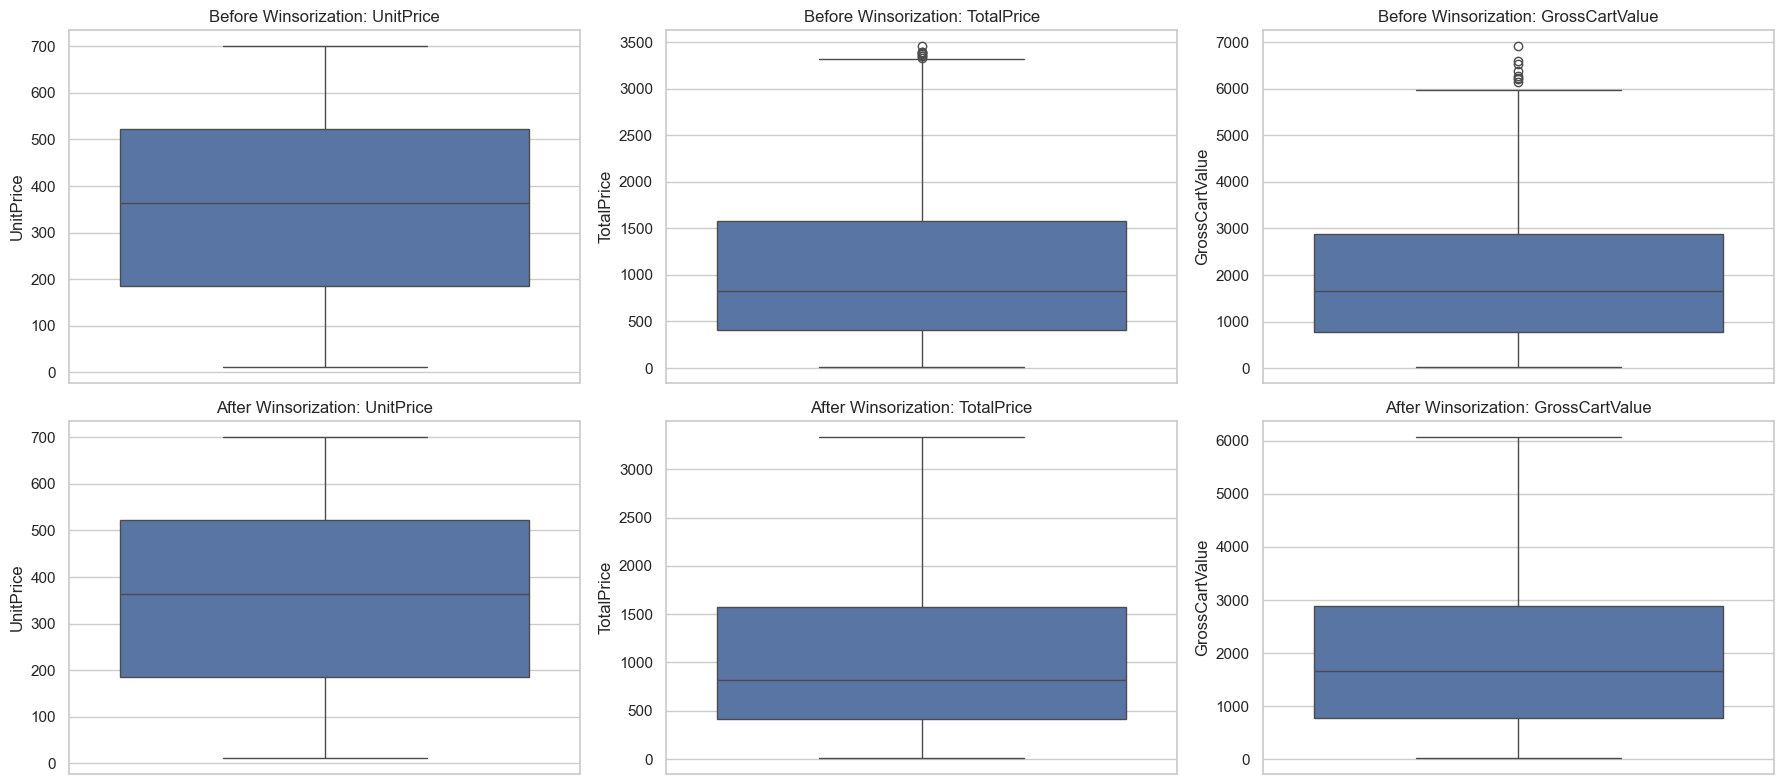

In [20]:
boxplot_columns = ["UnitPrice", "TotalPrice", "GrossCartValue"]

fig, axes = plt.subplots(2, len(boxplot_columns), figsize=(18, 8))

for index, column in enumerate(boxplot_columns):
    sns.boxplot(y=featured_df[column], ax=axes[0, index])
    axes[0, index].set_title(f"Before Winsorization: {column}")

    sns.boxplot(y=winsorized_df[column], ax=axes[1, index])
    axes[1, index].set_title(f"After Winsorization: {column}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "p1_winsorization_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Winsorization Impact
Before-and-after boxplots confirm that extreme values are capped while preserving the underlying dataset size.

This is suitable for downstream ML pipelines where row preservation matters.

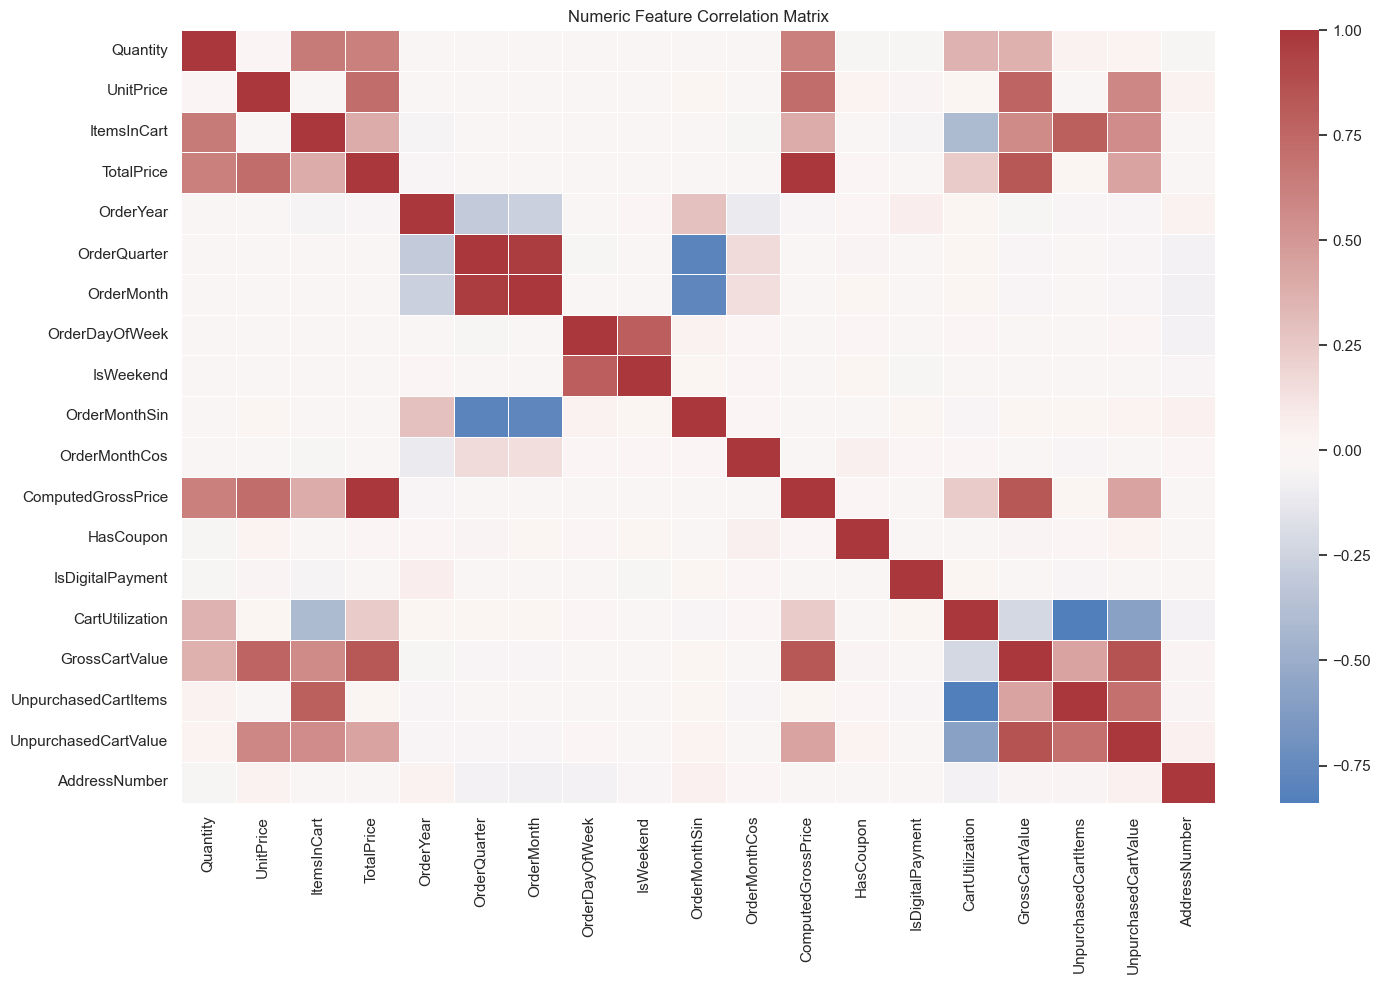

In [21]:
numeric_columns_for_corr = (
    winsorized_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

numeric_columns_for_corr = [
    column for column in numeric_columns_for_corr
    if winsorized_df[column].nunique(dropna=True) > 1
]

correlation_matrix = winsorized_df[numeric_columns_for_corr].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.4,
    linecolor="white"
)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "p1_numeric_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Correlation Analysis
The correlation matrix identifies redundant numeric relationships.

This is required before producing a stable downstream feature matrix.

In [22]:
TARGET_COLUMN = "TotalPrice"
CORRELATION_THRESHOLD = 0.80

absolute_corr = winsorized_df[numeric_columns_for_corr].corr().abs()
upper_triangle = absolute_corr.where(
    np.triu(np.ones(absolute_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    .query("correlation >= @CORRELATION_THRESHOLD")
    .sort_values("correlation", ascending=False)
    .reset_index(drop=True)
)

target_corr = (
    winsorized_df[numeric_columns_for_corr]
    .corr()[TARGET_COLUMN]
    .abs()
    if TARGET_COLUMN in numeric_columns_for_corr
    else pd.Series(0.0, index=numeric_columns_for_corr)
)

protected_business_features = {
    TARGET_COLUMN,
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "OrderYear",
    "OrderQuarter",
    "OrderMonth",
}

if not high_corr_pairs.empty:
    high_corr_pairs["feature_a_target_corr"] = high_corr_pairs["feature_a"].map(target_corr)
    high_corr_pairs["feature_b_target_corr"] = high_corr_pairs["feature_b"].map(target_corr)

    high_corr_pairs["drop_candidate"] = np.select(
        [
            high_corr_pairs["feature_a"].eq(TARGET_COLUMN),
            high_corr_pairs["feature_b"].eq(TARGET_COLUMN),
            high_corr_pairs["feature_a"].isin(protected_business_features)
            & ~high_corr_pairs["feature_b"].isin(protected_business_features),
            high_corr_pairs["feature_b"].isin(protected_business_features)
            & ~high_corr_pairs["feature_a"].isin(protected_business_features),
            high_corr_pairs["feature_a_target_corr"].ge(high_corr_pairs["feature_b_target_corr"]),
        ],
        [
            high_corr_pairs["feature_b"],
            high_corr_pairs["feature_a"],
            high_corr_pairs["feature_b"],
            high_corr_pairs["feature_a"],
            high_corr_pairs["feature_b"],
        ],
        default=high_corr_pairs["feature_a"],
    )

    redundant_numeric_features = sorted(
        set(high_corr_pairs["drop_candidate"]) - protected_business_features
    )
else:
    high_corr_pairs["feature_a_target_corr"] = pd.Series(dtype=float)
    high_corr_pairs["feature_b_target_corr"] = pd.Series(dtype=float)
    high_corr_pairs["drop_candidate"] = pd.Series(dtype=str)
    redundant_numeric_features = []

display(high_corr_pairs)
print(f"Redundant numeric features selected for removal: {redundant_numeric_features}")

,feature_a,feature_b,correlation,feature_a_target_corr,feature_b_target_corr,drop_candidate
0,TotalPrice,ComputedGrossPrice,1.0000,1.0000,1.0000,ComputedGrossPrice
1,OrderQuarter,OrderMonth,0.9691,0.0233,0.0278,OrderQuarter
2,GrossCartValue,UnpurchasedCartValue,0.8580,0.8403,0.4430,UnpurchasedCartValue
3,TotalPrice,GrossCartValue,0.8403,1.0000,0.8403,GrossCartValue
4,ComputedGrossPrice,GrossCartValue,0.8403,1.0000,0.8403,GrossCartValue
5,CartUtilization,UnpurchasedCartItems,0.8381,0.2330,0.0171,UnpurchasedCartItems


Redundant numeric features selected for removal: ['ComputedGrossPrice', 'GrossCartValue', 'UnpurchasedCartItems', 'UnpurchasedCartValue']


## Multicollinearity Eradication
Highly correlated numeric pairs are identified using an absolute correlation threshold of 0.80.

Where possible, the feature with weaker relationship to TotalPrice is removed, while business-critical base features are protected.

In [23]:
TARGET_DERIVED_COLUMNS = [
    "ComputedGrossPrice",
    "TotalPriceDelta",
    "TotalPriceDeltaAbs",
    "OrderValueSegment",
]

IDENTIFIER_COLUMNS = [
    "OrderID",
    "CustomerID",
    "TrackingNumber",
    "ShippingAddress",
]

DATE_COLUMNS = ["Date"]

feature_store_df = winsorized_df.copy()

leakage_and_redundancy_exclusions = sorted(
    set(IDENTIFIER_COLUMNS + DATE_COLUMNS + TARGET_DERIVED_COLUMNS + redundant_numeric_features)
)

modeling_df = winsorized_df.drop(
    columns=leakage_and_redundancy_exclusions,
    errors="ignore"
).copy()

if TARGET_COLUMN in modeling_df.columns:
    target_series = modeling_df[[TARGET_COLUMN]].copy()
    feature_input_df = modeling_df.drop(columns=[TARGET_COLUMN]).copy()
else:
    target_series = pd.DataFrame(index=modeling_df.index)
    feature_input_df = modeling_df.copy()

nominal_feature_columns = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource",
    "CouponFamily",
    "UnitPriceTier",
]

nominal_feature_columns_available = [
    column for column in nominal_feature_columns
    if column in feature_input_df.columns
]

numeric_model_columns = (
    feature_input_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

encoded_feature_df = pd.get_dummies(
    feature_input_df,
    columns=nominal_feature_columns_available,
    drop_first=False,
    dtype=np.int8
)

ml_ready_df = pd.concat([encoded_feature_df, target_series], axis=1)

print(f"Feature store shape: {feature_store_df.shape}")
print(f"Encoded ML-ready shape: {ml_ready_df.shape}")
display(ml_ready_df.head())

Feature store shape: (1200, 34)
Encoded ML-ready shape: (1200, 49)


,Quantity,UnitPrice,ItemsInCart,OrderYear,OrderQuarter,OrderMonth,OrderDayOfWeek,IsWeekend,OrderMonthSin,OrderMonthCos,HasCoupon,IsDigitalPayment,CartUtilization,AddressNumber,Product_Chair,Product_Desk,Product_Laptop,Product_Monitor,Product_Phone,Product_Printer,Product_Tablet,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_FREESHIP,CouponCode_NO_COUPON,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Email,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,CouponFamily_Discount10,CouponFamily_FreeShipping,CouponFamily_NoCoupon,CouponFamily_Seasonal15,UnitPriceTier_Budget,UnitPriceTier_High,UnitPriceTier_Luxury,UnitPriceTier_Standard,TotalPrice
0,5,570.6200,7,2023,1,1,2,0,0.5000,0.8660,1,1,0.7143,928,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,"2,853.1000"
1,2,151.3500,3,2024,3,8,4,0,-0.8660,-0.5000,1,1,0.6667,823,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,302.7000
2,5,550.6800,8,2024,1,2,1,0,0.8660,0.5000,1,1,0.6250,512,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,"2,753.4000"
3,1,273.1900,5,2023,4,10,6,1,-0.8660,0.5000,1,1,0.2000,275,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,273.1900
4,4,626.0100,8,2025,2,5,3,0,0.5000,-0.8660,1,1,0.5000,668,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,"2,504.0400"


## Categorical Translation and Leakage Control
Categorical features are translated using One-Hot Encoding.

The following are excluded from the modeling-ready matrix:

Raw identifiers
    
Raw date column
    
Target-derived features
    
Redundant collinear numeric features
    
This prevents leakage while preserving a clean feature store for audit and downstream use.

In [24]:
scaler_means = encoded_feature_df[numeric_model_columns].mean()
scaler_stds = encoded_feature_df[numeric_model_columns].std(ddof=0).replace(0, 1)

scaled_feature_df = encoded_feature_df.copy()
scaled_feature_df[numeric_model_columns] = (
    scaled_feature_df[numeric_model_columns] - scaler_means
) / scaler_stds

scaled_ml_ready_df = pd.concat([scaled_feature_df, target_series], axis=1)

display(scaled_ml_ready_df.head())

,Quantity,UnitPrice,ItemsInCart,OrderYear,OrderQuarter,OrderMonth,OrderDayOfWeek,IsWeekend,OrderMonthSin,OrderMonthCos,HasCoupon,IsDigitalPayment,CartUtilization,AddressNumber,Product_Chair,Product_Desk,Product_Laptop,Product_Monitor,Product_Phone,Product_Printer,Product_Tablet,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_FREESHIP,CouponCode_NO_COUPON,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Email,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,CouponFamily_Discount10,CouponFamily_FreeShipping,CouponFamily_NoCoupon,CouponFamily_Seasonal15,UnitPriceTier_Budget,UnitPriceTier_High,UnitPriceTier_Luxury,UnitPriceTier_Standard,TotalPrice
0,1.4600,1.0868,0.6642,-1.0225,-1.2103,-1.4942,-0.5189,-0.6521,0.5590,1.3109,0.5889,0.5078,0.5381,1.3720,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,"2,853.1000"
1,-0.6722,-1.0404,-1.0894,0.3097,0.6270,0.5998,0.4687,-0.6521,-1.4338,-0.5994,0.5889,0.5078,0.3475,0.9792,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,302.7000
2,1.4600,0.9857,1.1026,0.3097,-1.2103,-1.1951,-1.0126,-0.6521,1.0929,0.7990,0.5889,0.5078,0.1807,-0.1840,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,"2,753.4000"
3,-1.3830,-0.4222,-0.2126,-1.0225,1.5456,1.1981,1.4562,1.5336,-1.4338,0.7990,0.5889,0.5078,-1.5209,-1.0705,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,273.1900
4,0.7492,1.3679,1.1026,1.6420,-0.2917,-0.2976,-0.0251,-0.6521,0.5590,-1.1112,0.5889,0.5078,-0.3198,0.3995,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,"2,504.0400"


## Feature Scaling
Continuous numeric features are standardized for downstream ML compatibility.

One-Hot encoded categorical coordinates remain binary and are not manually altered beyond encoding.

In [25]:
feature_store_csv_path = PROCESSED_DATA_DIR / "p1_clean_feature_store.csv"
ml_ready_csv_path = PROCESSED_DATA_DIR / "p1_ml_ready_encoded.csv"
scaled_ml_ready_csv_path = PROCESSED_DATA_DIR / "p1_ml_ready_encoded_scaled.csv"

missing_summary_path = REPORTS_DIR / "p1_missing_summary.csv"
contract_report_path = REPORTS_DIR / "p1_contract_report.csv"
outlier_report_path = REPORTS_DIR / "p1_outlier_report.csv"
collinearity_report_path = REPORTS_DIR / "p1_collinearity_report.csv"

feature_store_df.to_csv(feature_store_csv_path, index=False)
ml_ready_df.to_csv(ml_ready_csv_path, index=False)
scaled_ml_ready_df.to_csv(scaled_ml_ready_csv_path, index=False)

missing_summary.to_csv(missing_summary_path)
contract_report.to_csv(contract_report_path, index=False)
outlier_report.to_csv(outlier_report_path)
high_corr_pairs.to_csv(collinearity_report_path, index=False)

export_summary = pd.DataFrame({
    "artifact": [
        "Clean feature store",
        "ML-ready encoded dataset",
        "Scaled ML-ready encoded dataset",
        "Missing summary",
        "Contract validation report",
        "Outlier report",
        "Collinearity report",
    ],
    "path": [
        str(feature_store_csv_path),
        str(ml_ready_csv_path),
        str(scaled_ml_ready_csv_path),
        str(missing_summary_path),
        str(contract_report_path),
        str(outlier_report_path),
        str(collinearity_report_path),
    ],
})

display(export_summary)

,artifact,path
0,Clean feature store,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
1,ML-ready encoded dataset,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
2,Scaled ML-ready encoded dataset,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
3,Missing summary,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
4,Contract validation report,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
5,Outlier report,C:\Users\Kyous\Videos\Internship\Project 1\Pro...
6,Collinearity report,C:\Users\Kyous\Videos\Internship\Project 1\Pro...


## Dataset and Report Export
The notebook exports both analytical and ML-ready assets:

Clean feature store for inspection and feature reuse

Encoded coordinate matrix for downstream ML

Scaled coordinate matrix for algorithms sensitive to magnitude

Data quality and transformation reports

In [26]:
feature_engineering_artifact = {
    "project_name": "P1 Advanced EDA and Feature Engineering",
    "expected_columns": EXPECTED_COLUMNS,
    "text_columns": TEXT_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
    "training_critical_columns": TRAINING_CRITICAL_COLUMNS,
    "serving_required_columns": SERVING_REQUIRED_COLUMNS,
    "target_column": TARGET_COLUMN,
    "numeric_impute_values": numeric_impute_values.to_dict(),
    "categorical_impute_values": categorical_impute_values,
    "unit_price_bins": UNIT_PRICE_BINS,
    "unit_price_labels": UNIT_PRICE_LABELS,
    "total_price_bins": TOTAL_PRICE_BINS,
    "total_price_labels": ORDER_VALUE_LABELS,
    "continuous_numeric_columns": CONTINUOUS_NUMERIC_COLUMNS,
    "winsor_lower_bounds": lower_bounds.to_dict(),
    "winsor_upper_bounds": upper_bounds.to_dict(),
    "redundant_numeric_features": redundant_numeric_features,
    "target_derived_columns": TARGET_DERIVED_COLUMNS,
    "identifier_columns": IDENTIFIER_COLUMNS,
    "date_columns": DATE_COLUMNS,
    "nominal_feature_columns": nominal_feature_columns_available,
    "numeric_model_columns": numeric_model_columns,
    "encoded_feature_columns": encoded_feature_df.columns.tolist(),
    "scaler_means": scaler_means.to_dict(),
    "scaler_stds": scaler_stds.to_dict(),
}

def transform_new_orders_for_serving(
    new_orders_df: pd.DataFrame,
    artifact: dict
) -> pd.DataFrame:
    df_new = normalize_column_names(new_orders_df)
    df_new = df_new.reindex(columns=artifact["expected_columns"])
    df_new = normalize_and_cast_orders(df_new)

    required_columns = [
        column for column in artifact["serving_required_columns"]
        if column in df_new.columns
    ]

    df_new = df_new.dropna(subset=required_columns).copy()

    df_new["CouponCode"] = df_new["CouponCode"].fillna("NO_COUPON")

    numeric_impute_series = pd.Series(artifact["numeric_impute_values"])
    categorical_impute_series = pd.Series(artifact["categorical_impute_values"])

    numeric_columns_available = [
        column for column in artifact["numeric_columns"]
        if column in df_new.columns
    ]

    categorical_columns_available = [
        column for column in categorical_impute_series.index
        if column in df_new.columns
    ]

    df_new[numeric_columns_available] = df_new[numeric_columns_available].fillna(
        numeric_impute_series.reindex(numeric_columns_available)
    )

    df_new[categorical_columns_available] = df_new[categorical_columns_available].fillna(
        categorical_impute_series.reindex(categorical_columns_available)
    )

    df_new = engineer_order_features(
        df_new,
        unit_price_bins=artifact["unit_price_bins"],
        total_price_bins=artifact["total_price_bins"],
    )

    winsor_columns_available = [
        column for column in artifact["continuous_numeric_columns"]
        if column in df_new.columns
    ]

    lower_series = pd.Series(artifact["winsor_lower_bounds"]).reindex(winsor_columns_available)
    upper_series = pd.Series(artifact["winsor_upper_bounds"]).reindex(winsor_columns_available)

    df_new[winsor_columns_available] = df_new[winsor_columns_available].clip(
        lower=lower_series,
        upper=upper_series,
        axis=1,
    )

    drop_columns = (
        artifact["identifier_columns"]
        + artifact["date_columns"]
        + artifact["target_derived_columns"]
        + artifact["redundant_numeric_features"]
        + [artifact["target_column"]]
    )

    serving_feature_df = df_new.drop(columns=drop_columns, errors="ignore")

    nominal_columns_available = [
        column for column in artifact["nominal_feature_columns"]
        if column in serving_feature_df.columns
    ]

    serving_encoded_df = pd.get_dummies(
        serving_feature_df,
        columns=nominal_columns_available,
        drop_first=False,
        dtype=np.int8,
    )

    serving_encoded_df = serving_encoded_df.reindex(
        columns=artifact["encoded_feature_columns"],
        fill_value=0,
    )

    scaling_columns_available = [
        column for column in artifact["numeric_model_columns"]
        if column in serving_encoded_df.columns
    ]

    mean_series = pd.Series(artifact["scaler_means"]).reindex(scaling_columns_available)
    std_series = pd.Series(artifact["scaler_stds"]).reindex(scaling_columns_available)

    serving_encoded_df[scaling_columns_available] = (
        serving_encoded_df[scaling_columns_available] - mean_series
    ) / std_series

    return serving_encoded_df

sample_serving_features = transform_new_orders_for_serving(
    raw_df.iloc[[0]].copy(),
    feature_engineering_artifact
)

print(f"Serving feature vector shape: {sample_serving_features.shape}")
display(sample_serving_features.head())

Serving feature vector shape: (1, 48)


,Quantity,UnitPrice,ItemsInCart,OrderYear,OrderQuarter,OrderMonth,OrderDayOfWeek,IsWeekend,OrderMonthSin,OrderMonthCos,HasCoupon,IsDigitalPayment,CartUtilization,AddressNumber,Product_Chair,Product_Desk,Product_Laptop,Product_Monitor,Product_Phone,Product_Printer,Product_Tablet,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_FREESHIP,CouponCode_NO_COUPON,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Email,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,CouponFamily_Discount10,CouponFamily_FreeShipping,CouponFamily_NoCoupon,CouponFamily_Seasonal15,UnitPriceTier_Budget,UnitPriceTier_High,UnitPriceTier_Luxury,UnitPriceTier_Standard
0,1.4600,1.0868,0.6642,-1.0225,-1.2103,-1.4942,-0.5189,-0.6521,0.5590,1.3109,0.5889,0.5078,0.5381,1.3720,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0


## Deployment-Style Feature Transformation
A reusable transformation function is created for new order records.

It applies the same production logic used during training preparation:

Schema alignment

Type casting

Missing value policy

Feature engineering

Winsorization

One-Hot Encoding

Scaling

Column alignment

In [27]:
# Final Model Saving Code Cell

feature_pipeline_artifact_path = ARTIFACTS_DIR / "p1_feature_engineering_pipeline.pkl"

joblib.dump(feature_engineering_artifact, feature_pipeline_artifact_path)

print(f"Saved P1 feature engineering artifact: {feature_pipeline_artifact_path}")

Saved P1 feature engineering artifact: C:\Users\Kyous\Videos\Internship\Project 1\Project 1\artifacts\p1_feature_engineering_pipeline.pkl


## Deployment Readiness
The serialized artifact contains the complete feature engineering contract:

Expected schema

Imputation values

Winsorization boundaries

Engineered feature configuration

Redundant feature exclusions

One-Hot encoded coordinate columns

Scaling parameters

This enables consistent training-serving behavior for downstream machine learning projects.